# Guillotine — Commercial Model Analysis

This is a separate notebook from `ghigliottina_analisi_locali.ipynb`, and the split reflects
experimental design, not convenience: these models run with **a single
run, with no sampling parameters set** (temperature, top_p, top_k left
at the provider's default) — for cost reasons, not because it is
technically impossible to control them (that would be possible via the
API). Direct consequence: **no temperature axis** (RQ4 does not apply —
there is no repetition to compare) and **no RQ5** (top-tier proprietary
models do not disclose their parameter counts).

What remains valid and is redone here: leaderboard with confidence
intervals, hardest items, item discrimination, response frequency,
instruction echo, pairwise model comparison.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", None)

In [2]:
RESULTS_FILE = r"D:\guillotine\guillotine\source\complete_ghigliottina_results.xlsx"
SHEET_NAME = "Commercial"

data = pd.read_excel(RESULTS_FILE, sheet_name=SHEET_NAME, engine="openpyxl")
print(f"Total rows: {len(data)}")
print(f"Models: {data['model_name'].nunique()}")
data.head()

Total rows: 480
Models: 16


,model_name,prompt_id,word1,word2,word3,word4,word5,expected_solution,raw_response,predicted_word,format_compliant,exact_match,same_root,levenshtein_normalized,is_similar_lev,is_clue_echo,synonym_manual,coherence_manual,timestamp,difficulty_note,duration_s,is_first_call,status
0,openai/gpt-5.4-mini,guillo_02,highway,wheel,transport,fuel,insurance,car,AUTO,AUTO,1,0,0,1.0000,0,0,1,1,2026-08-30 12:35:30,easy,1.9,0,ok
1,cohere/command-a,guillo_02,highway,wheel,transport,fuel,insurance,car,VEHICLE,VEHICLE,1,0,0,0.8571,0,0,1,1,2026-08-30 12:38:59,easy,0.5,0,ok
2,z-ai/glm-5.3,guillo_23,philosophy,math,physics,business,society,concept,<think>Let me think about this. I need a word ...,THEORY,1,0,0,1.0000,0,0,1,1,2026-08-29 23:37:08,hard,7.6,0,ok
3,openai/gpt-5.5,guillo_23,philosophy,math,physics,business,society,concept,"<think>**Exploring concepts of ""quantum"" and ""...",THEORY,1,0,0,1.0000,0,0,1,1,2026-08-30 12:16:12,hard,8.0,0,ok
4,openai/gpt-5.4,guillo_23,philosophy,math,physics,business,society,concept,THEORY,THEORY,1,0,0,1.0000,0,0,1,1,2026-08-30 12:34:58,hard,0.9,0,ok


## Coverage and status

In [3]:
status_counts = data["status"].value_counts()
print(status_counts)

coverage = data.groupby("model_name")["status"].value_counts().unstack(fill_value=0)
coverage["n_total"] = coverage.sum(axis=1)
coverage

status
ok       444
error     36
Name: count, dtype: int64


status,error,ok,n_total
model_name,,,
anthropic/claude-haiku-4.5,0,30,30
anthropic/claude-opus-5,0,30,30
anthropic/claude-sonnet-5,0,30,30
cohere/command-a,0,30,30
deepseek/deepseek-v4-pro-0813,0,30,30
google/gemini-3.7-flash,0,30,30
inception/mercury-2,6,24,30
meta/muse-spark-1.2,30,0,30
moonshotai/kimi-k3,0,30,30


In [4]:
ok_data = data[data["status"] == "ok"].copy()

manual_coverage = pd.Series({
    "synonym_manual": ok_data["synonym_manual"].notna().mean(),
    "coherence_manual": ok_data["coherence_manual"].notna().mean(),
})
print("Share of manual review completed:")
print(manual_coverage.round(3))
if (manual_coverage < 1.0).any():
    print("\nWARNING: manual review incomplete - the 'extended' rates below are partial.")

Share of manual review completed:
synonym_manual      1.0
coherence_manual    1.0
dtype: float64


## Leaderboard with confidence interval (Wilson)

Same method as the local notebook — observed proportion + 95% CI,
not just the point estimate. With a single run per model (30
observations), the intervals will be wider than in the local dataset's
90 observations per model: expected, not a flaw in the calculation.

In [5]:
leaderboard = ok_data.groupby("model_name").agg(
    n=("exact_match", "size"),
    exact_match=("exact_match", "mean"),
    same_root=("same_root", "mean"),
    is_similar_lev=("is_similar_lev", "mean"),
    format_compliant=("format_compliant", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
).sort_values("exact_match", ascending=False)

successes = (leaderboard["exact_match"] * leaderboard["n"]).round().astype(int)
leaderboard["ci_low"], leaderboard["ci_high"] = proportion_confint(successes, leaderboard["n"], method="wilson")
leaderboard.round(3)

,n,exact_match,same_root,is_similar_lev,format_compliant,is_clue_echo,ci_low,ci_high
model_name,,,,,,,,
x-ai/grok-4.6,30,0.767,0.833,0.833,1.000,0.0,0.591,0.882
google/gemini-3.7-flash,30,0.733,0.800,0.800,1.000,0.0,0.556,0.858
anthropic/claude-opus-5,30,0.700,0.767,0.767,1.000,0.0,0.521,0.833
moonshotai/kimi-k3,30,0.700,0.767,0.767,0.933,0.0,0.521,0.833
openai/gpt-5.6-sol,30,0.700,0.767,0.767,1.000,0.0,0.521,0.833
openai/gpt-5.5,30,0.667,0.733,0.733,1.000,0.0,0.488,0.808
anthropic/claude-sonnet-5,30,0.667,0.733,0.733,1.000,0.0,0.488,0.808
z-ai/glm-5.3,30,0.667,0.733,0.733,0.867,0.0,0.488,0.808
deepseek/deepseek-v4-pro-0813,30,0.633,0.700,0.700,1.000,0.0,0.455,0.781


In [6]:
# Full version, without truncation, ready to copy (e.g. into Word).
# The table above is already complete in this notebook (15 models, no
# hidden rows), but Jupyter's HTML rendering may not paste well
# outside the notebook - below is the same table as plain text.
pd.set_option("display.max_rows", None)

full_leaderboard = leaderboard.round(3).reset_index().rename(columns={"model_name": "Model"})
full_leaderboard.insert(0, "#", range(1, len(full_leaderboard) + 1))
print(f"Full leaderboard, {len(full_leaderboard)} models out of 16 (meta/muse-spark-1.2 excluded, 0 valid observations):\n")
print(full_leaderboard.to_string(index=False))

Full leaderboard, 15 models out of 16 (meta/muse-spark-1.2 excluded, 0 valid observations):

 #                         Model  n  exact_match  same_root  is_similar_lev  format_compliant  is_clue_echo  ci_low  ci_high
 1                 x-ai/grok-4.6 30        0.767      0.833           0.833             1.000           0.0   0.591    0.882
 2       google/gemini-3.7-flash 30        0.733      0.800           0.800             1.000           0.0   0.556    0.858
 3       anthropic/claude-opus-5 30        0.700      0.767           0.767             1.000           0.0   0.521    0.833
 4            moonshotai/kimi-k3 30        0.700      0.767           0.767             0.933           0.0   0.521    0.833
 5            openai/gpt-5.6-sol 30        0.700      0.767           0.767             1.000           0.0   0.521    0.833
 6                openai/gpt-5.5 30        0.667      0.733           0.733             1.000           0.0   0.488    0.808
 7     anthropic/claude-sonnet-5

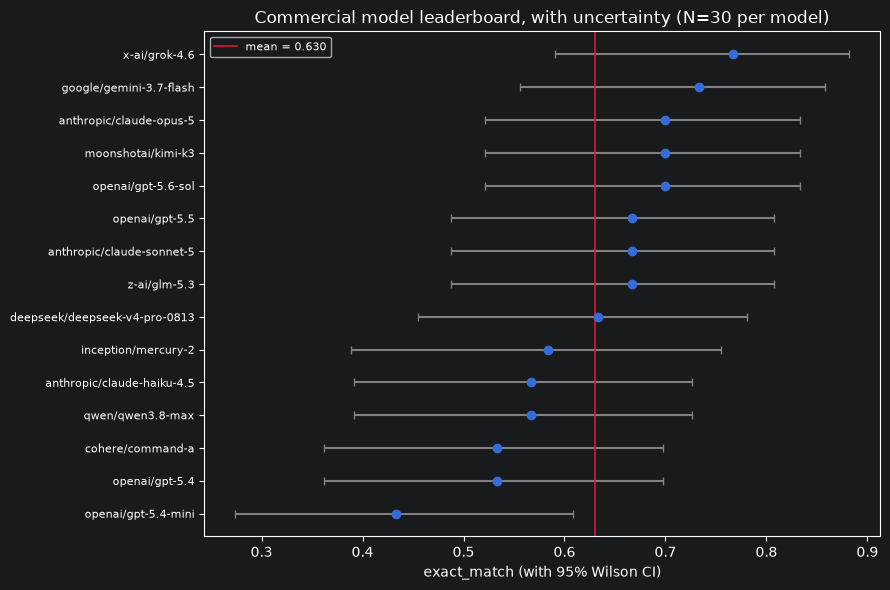

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(leaderboard))
ax.errorbar(
    leaderboard["exact_match"], y,
    xerr=[leaderboard["exact_match"] - leaderboard["ci_low"], leaderboard["ci_high"] - leaderboard["exact_match"]],
    fmt="o", capsize=3, ecolor="gray",
)
mean_val = leaderboard["exact_match"].mean()
ax.axvline(mean_val, color="crimson", linestyle="-", linewidth=1.2, label=f"mean = {mean_val:.3f}")
ax.legend(fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(leaderboard.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("exact_match (with 95% Wilson CI)")
ax.set_title("Commercial model leaderboard, with uncertainty (N=30 per model)")
plt.tight_layout()
plt.show()

## Extended correctness

Breakdown of the same score: how much comes from an exact match,
how much from a common root, how much from a manually judged synonym.

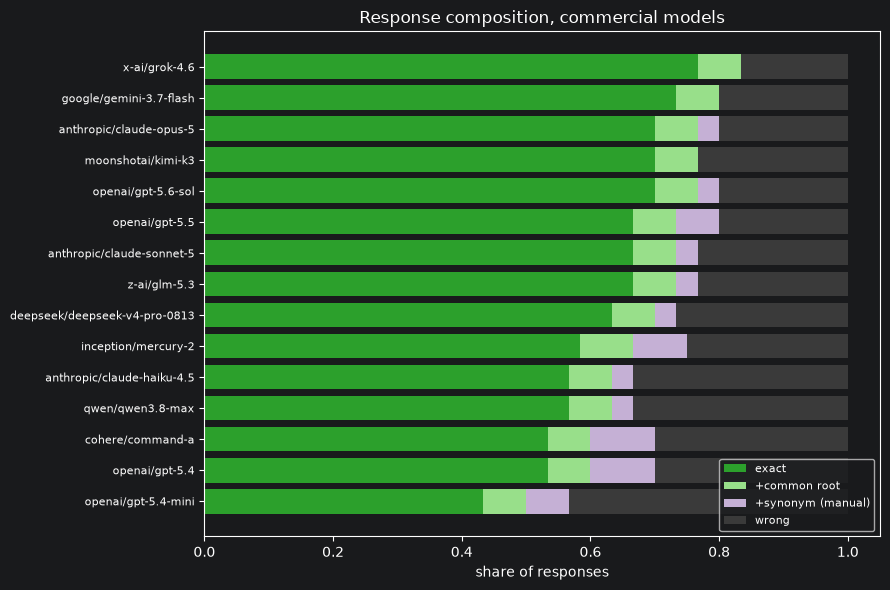

In [8]:
ok_data["same_root_only"] = ((ok_data["same_root"] == 1) & (ok_data["exact_match"] == 0)).astype(int)
ok_data["synonym_only"] = (
    (ok_data["synonym_manual"] == 1) & (ok_data["exact_match"] == 0) & (ok_data["same_root"] == 0)
).astype(int)

extended = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
    synonym_only=("synonym_only", "mean"),
).sort_values("exact_match", ascending=False)
extended["wrong"] = 1 - extended.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(extended))
left = np.zeros(len(extended))
colors = {"exact_match": "#2ca02c", "same_root_only": "#98df8a", "synonym_only": "#c5b0d5", "wrong": "#3a3a3a"}
labels = {"exact_match": "exact", "same_root_only": "+common root", "synonym_only": "+synonym (manual)", "wrong": "wrong"}
for col in ["exact_match", "same_root_only", "synonym_only", "wrong"]:
    ax.barh(y, extended[col], left=left, color=colors[col], label=labels[col])
    left += extended[col].values
ax.set_yticks(y)
ax.set_yticklabels(extended.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("share of responses")
ax.set_title("Response composition, commercial models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Item difficulty

In [9]:
by_item = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    expected_solution=("expected_solution", "first"),
    difficulty_note=("difficulty_note", "first"),
).sort_values("exact_match")

print("Hardest items, even for commercial models:")
by_item.head(10).round(3)

Hardest items, even for commercial models:


,exact_match,is_clue_echo,expected_solution,difficulty_note
prompt_id,,,,
guillo_15,0.000,0.0,statistic,medium
guillo_10,0.000,0.0,pc,easy
guillo_22,0.000,0.0,emotion,medium
guillo_18,0.000,0.0,watching,medium
guillo_29,0.000,0.0,scraping,hard
guillo_23,0.000,0.0,concept,hard
guillo_03,0.200,0.0,city,medium
guillo_21,0.200,0.0,supermarket,medium
guillo_09,0.267,0.0,petrichor,hard


## Response frequency per item

Same analysis as the local notebook - which words are actually given
as answers, not just whether they are correct.

In [10]:
word_freq_by_item = {}
for prompt_id, sub in ok_data.groupby("prompt_id"):
    word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()

top_answer_by_item = pd.DataFrame({
    pid: {"most_common_answer": freq.index[0], "n_times": freq.iloc[0], "n_models_total": freq.sum()}
    for pid, freq in word_freq_by_item.items()
}).T
top_answer_by_item["share"] = (top_answer_by_item["n_times"] / top_answer_by_item["n_models_total"]).round(3)
top_answer_by_item.sort_values("share", ascending=False)

,most_common_answer,n_times,n_models_total,share
guillo_16,PLANE,15,15,1.0
guillo_11,PYTHON,15,15,1.0
guillo_28,MOUSE,15,15,1.0
guillo_27,SUSTAINABILITY,15,15,1.0
guillo_25,APPLE,15,15,1.0
guillo_18,WATCH,15,15,1.0
guillo_17,FLAG,15,15,1.0
guillo_15,STATISTICS,15,15,1.0
guillo_30,PRESENT,15,15,1.0
guillo_05,LIGHT,15,15,1.0


## Instruction echo ("ONLY")

Same distinction as the local notebook: final answer literally
"ONLY" (a true failure) versus "ONLY" appearing somewhere in the
text (often just a harmless echo of the prompt).

In [11]:
only_exact = ok_data[ok_data["predicted_word"].astype(str).str.strip().str.upper() == "ONLY"]
only_in_text = ok_data["raw_response"].astype(str).str.upper().str.contains("ONLY", na=False)

print(f"predicted_word exactly 'ONLY': {len(only_exact)} / {len(ok_data)}")
print(f"'ONLY' present in raw_response: {only_in_text.sum()} / {len(ok_data)} ({100*only_in_text.mean():.1f}%)")
if len(only_exact) > 0:
    print("\nModels involved:")
    print(only_exact.groupby("model_name").size())
else:
    print("\nNo commercial model literally answered 'ONLY' as its final word.")

predicted_word exactly 'ONLY': 0 / 444
'ONLY' present in raw_response: 98 / 444 (22.1%)

No commercial model literally answered 'ONLY' as its final word.


## Observed reasoning (`<think>`)

No marker list here (these are different models from the local ones) -
just the direct empirical signal, and the average duration for models
that show it.

In [12]:
ok_data["has_think_tag"] = ok_data["raw_response"].astype(str).str.contains("<think>", na=False)
think_by_model = ok_data.groupby("model_name")["has_think_tag"].mean()

print("Share of responses with <think> observed, by model:")
print(think_by_model[think_by_model > 0].sort_values(ascending=False).round(3))

reasoning_models = think_by_model[think_by_model > 0].index
if len(reasoning_models) > 0:
    dur_compare = ok_data.groupby(ok_data["model_name"].isin(reasoning_models))["duration_s"].mean()
    dur_compare.index = ["without <think>", "with <think>"]
    print("\nAverage generation duration:")
    print(dur_compare.round(1))

Share of responses with <think> observed, by model:
model_name
anthropic/claude-opus-5          1.000
google/gemini-3.7-flash          1.000
z-ai/glm-5.3                     1.000
moonshotai/kimi-k3               1.000
x-ai/grok-4.6                    1.000
qwen/qwen3.8-max                 1.000
anthropic/claude-sonnet-5        0.900
deepseek/deepseek-v4-pro-0813    0.733
openai/gpt-5.6-sol               0.533
openai/gpt-5.5                   0.500
Name: has_think_tag, dtype: float64

Average generation duration:
without <think>     1.2
with <think>       87.3
Name: duration_s, dtype: float64


## Item discrimination index (Classical Test Theory)

Point-biserial correlation between an item's outcome and the model's
total score - an item discriminates well if strong models pass it and
weak models don't, and discriminates poorly if all models pass it or
all fail it alike.

In [13]:
model_totals = ok_data.groupby("model_name")["exact_match"].mean()
pivot_items = ok_data.pivot_table(index="model_name", columns="prompt_id", values="exact_match")

discrimination = {}
for item in pivot_items.columns:
    item_scores = pivot_items[item].dropna()
    if item_scores.nunique() < 2:
        continue
    total_minus_item = model_totals.loc[item_scores.index]
    discrimination[item] = stats.pointbiserialr(item_scores, total_minus_item).correlation

disc_series = pd.Series(discrimination, name="discrimination").sort_values()
disc_df = disc_series.to_frame().join(by_item[["expected_solution", "exact_match"]])
print("Items with the lowest or negative discrimination (uninformative or problematic):")
disc_df.head(30).round(3)

Items with the lowest or negative discrimination (uninformative or problematic):


,discrimination,expected_solution,exact_match
guillo_01,-0.129,chair,0.786
guillo_03,0.272,city,0.200
guillo_20,0.292,travel,0.733
guillo_12,0.294,title,0.933
guillo_24,0.331,idea,0.357
guillo_21,0.525,supermarket,0.200
guillo_09,0.538,petrichor,0.267
guillo_02,0.564,car,0.667
guillo_14,0.599,mandala,0.933
guillo_06,0.605,civilization,0.857


## Pairwise model comparison (McNemar + FDR correction)

Same principle as the local notebook: paired data on the same items,
not an independent test. With N=30 items per model (versus 90 in the
local dataset), statistical power is lower - expect even fewer
significant comparisons after correction.

In [14]:
top_n = 8
top_models = leaderboard.head(top_n).index.tolist()

pairs_results = []
for i in range(len(top_models)):
    for j in range(i + 1, len(top_models)):
        m1, m2 = top_models[i], top_models[j]
        s1 = ok_data[ok_data["model_name"] == m1].set_index("prompt_id")["exact_match"]
        s2 = ok_data[ok_data["model_name"] == m2].set_index("prompt_id")["exact_match"]
        common = s1.index.intersection(s2.index)
        if len(common) < 10:
            continue
        s1, s2 = s1.loc[common], s2.loc[common]
        table = pd.crosstab(s1, s2)
        table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        result = mcnemar(table.values, exact=True)
        pairs_results.append({"model_1": m1, "model_2": m2, "n_items": len(common), "p_value": result.pvalue})

pairs_df = pd.DataFrame(pairs_results)
if len(pairs_df) > 0:
    pairs_df["p_fdr"] = multipletests(pairs_df["p_value"], method="fdr_bh")[1]
    n_sig = (pairs_df["p_fdr"] < 0.05).sum()
    print(f"Pairs tested: {len(pairs_df)}, significant after FDR correction: {n_sig}")
    pairs_df.sort_values("p_value").round(4)
else:
    print("Not enough shared items for a reliable pairwise comparison.")

Pairs tested: 28, significant after FDR correction: 0


## Qualitative comparison: commercial vs. the rest of the roster

Same items - do the two groups find them similarly difficult, or
differently? Requires also loading the controlled-temperature dataset
for comparison - optional section, skip if the file isn't available
right now.

Spearman (item difficulty, rest of roster vs. commercial): rho=0.866, p=0.0000
-> same notion of item difficulty, regardless of model tier


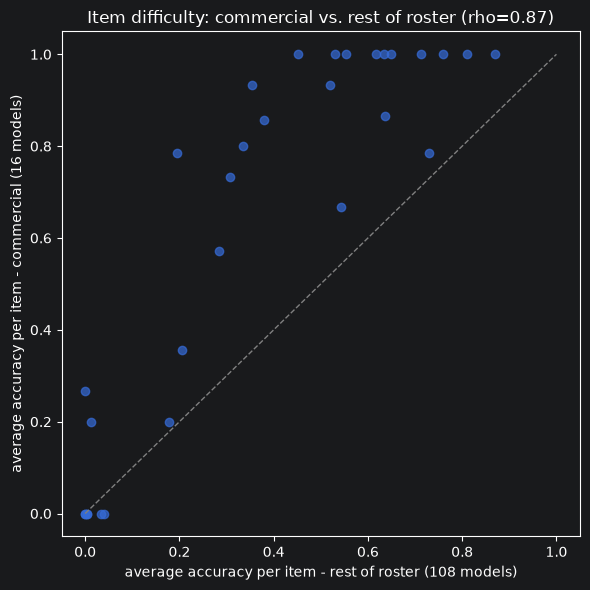

In [15]:
try:
    RUN_SHEETS = ["T_0.0", "T_0.3", "T_0.7"]
    frames = []
    for sheet in RUN_SHEETS:
        df = pd.read_excel(RESULTS_FILE, sheet_name=sheet, engine="openpyxl")
        frames.append(df)
    other_data = pd.concat(frames, ignore_index=True)
    other_ok = other_data[other_data["status"] == "ok"].copy()

    by_item_other = other_ok.groupby("prompt_id")["exact_match"].mean()
    by_item_commercial = ok_data.groupby("prompt_id")["exact_match"].mean()

    common_items = by_item_other.index.intersection(by_item_commercial.index)
    rho, p = stats.spearmanr(by_item_other.loc[common_items], by_item_commercial.loc[common_items])
    print(f"Spearman (item difficulty, rest of roster vs. commercial): rho={rho:.3f}, p={p:.4f}")
    print("-> same notion of item difficulty, regardless of model tier"
          if rho > 0.5 else "-> the two model populations find different items difficult, not a given")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(by_item_other.loc[common_items], by_item_commercial.loc[common_items], alpha=0.7)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("average accuracy per item - rest of roster (108 models)")
    ax.set_ylabel("average accuracy per item - commercial (16 models)")
    ax.set_title(f"Item difficulty: commercial vs. rest of roster (rho={rho:.2f})")
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("Main dataset file not found right now - section skipped, not essential.")

## Limitations of this part of the study

- A single run per model (30 observations) — wider confidence intervals
  than in the local dataset, less power for pairwise comparisons.
- No control over sampling parameters — each provider used its own
  default, not necessarily comparable across providers.
- RQ4 (temperature) and RQ5 (size) do not apply by construction, not
  by an analysis choice.
- The reason for the single run is cost, not the technical impossibility
  of controlling the parameters — this must be stated explicitly in the
  whitepaper; it is a different (and weaker) limitation than that of the
  old 10 models collected by hand via copy-paste.